## Objectif du projet

Ce notebook présente un projet de détection de fraude par carte bancaire.
L’objectif est d’identifier les transactions potentiellement frauduleuses à l’aide de modèles de Machine Learning, dans un contexte de données fortement déséquilibrées.


# 1. Exploration Initiale des Données (EDA)

Cette section vise a comprendre la structure du jeu de données, la qualité des variables et les premières tendances statistiques.

### 1.1 import CSV

In [1]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [2]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Préprocessing et Modélisation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score
from xgboost import XGBClassifier
import shap

# Configuration de l'affichage des graphiques
sns.set(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (6, 4)

# Configuration de SHAP pour les visualisations JavaScript
shap.initjs()

### 1.2 Chargement des données

In [3]:
# Chargement du fichier CSV dans un DataFrame pandas
df = pd.read_csv('creditcard.csv')

# Nettoyage des noms de colonnes pour supprimer les espaces éventuels
df.columns = df.columns.str.strip()

# Aperçu et infos générales
display(df.head())
print(df.info())
print(df.isnull().sum())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 1.3 Variables cibles et catégories métier

In [4]:
df['Transaction_Type'] = df['Class'].map({0:'Normal',1:'Fraude'})

La colonne Class indique si la transaction est normale (0) ou frauduleuse (1).
Pour faciliter la lecture, on crée une variable plus lisible :

In [5]:
# On catégorise également les montants pour simplifier les analyses metier :
def amount_category(amount):
    if amount < 10: return 'Très faible'
    elif amount < 50: return 'Faible'
    elif amount < 200: return 'Moyen'
    else: return 'Élevé'
df['Amount_Category'] = df['Amount'].apply(amount_category)


Le jeu de données est très déséquilibré : les fraudes représentent moins de 0,2 % des transactions.

In [6]:
print(df['Class'].value_counts())
print((df['Class'].value_counts(normalize=True)*100))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Ce déséquilibre implique qu’un modèle naïf prédisant uniquement des transactions normales obtiendrait une excellente accuracy, tout en étant inutile en pratique.


### 1.4 Visualisations

1.4.1 Distribution des montants

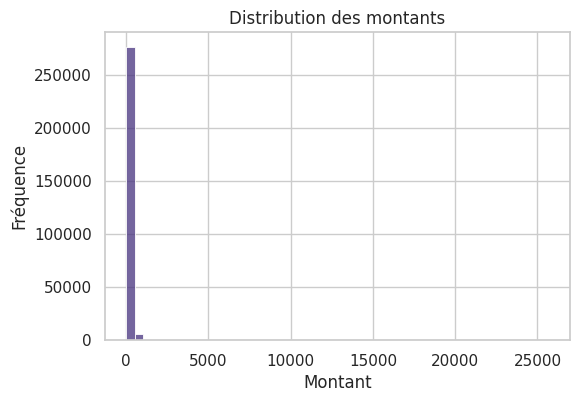

In [7]:
# Distribution globale des montants
sns.histplot(df['Amount'], bins=50)
plt.title("Distribution des montants")
plt.xlabel("Montant")
plt.ylabel("Fréquence")
plt.show()

La majorité des transactions sont de faible montant, avec une longue traîne vers des montants élevés. Cela confirme l'intérêt de s'appuyer sur des variables comportementales (V1 à V28) plutot que sur le seul montant.

1.4.2 Répartition des transactions

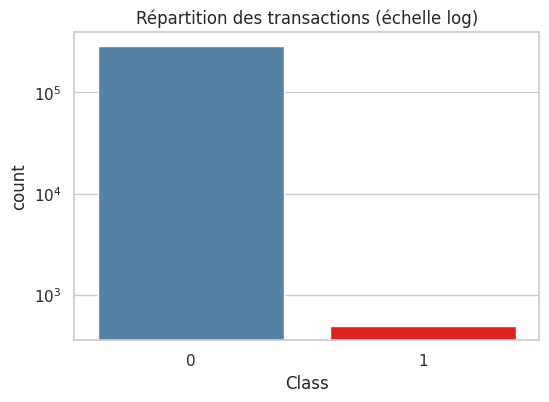

In [8]:
sns.countplot(x="Class", hue="Class", data=df, palette={0:"steelblue",1:"red"}, legend=False)
plt.yscale("log")
plt.title("Répartition des transactions (échelle log)")
plt.show()

L’échelle logarithmique permet de visualiser la classe minoritaire (fraudes).

1.4.3 Montants par type de transaction

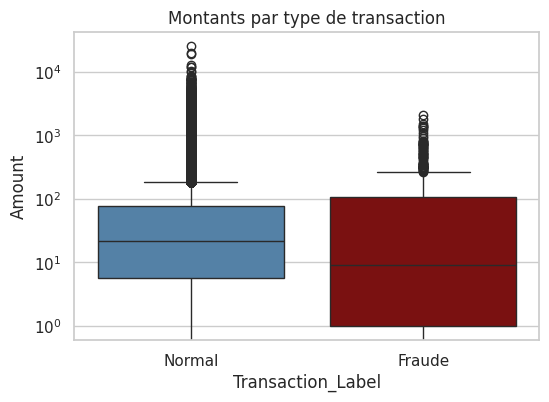

In [9]:
df["Transaction_Label"] = df["Class"].map({0:"Normal",1:"Fraude"})
sns.boxplot(x="Transaction_Label", y="Amount", hue="Transaction_Label",
            data=df, palette={"Normal":"steelblue","Fraude":"darkred"}, legend=False)
plt.yscale("log")
plt.title("Montants par type de transaction")
plt.show()

Les fraudes sont très variables, souvent faibles à moyennes. Le montant seul n’est pas suffisant pour détecter la fraude.

 # 2. Préparation pour ML

On commence par sélectionner les colonnes numériques pertinentes et figer explicitement les features utilisées.

In [10]:
cols_to_drop = ["Class", "Transaction_Type", "Transaction_Label", "Amount_Category", "Fraud_Prediction", "Fraud_Prediction_Label"]
X = df.drop(columns=cols_to_drop, errors="ignore").select_dtypes(include=[np.number])
y = df["Class"]

feature_columns = X.columns.tolist()  # Colonnes utilisées par le modèle

### 2.1 Split train/test

In [11]:
# Split train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X[feature_columns], y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Le jeu de test permet d’évaluer la performance du modèle sur des données
qu’il n’a jamais vues. Cela permet d’éviter l’overfitting et d’estimer
la capacité de généralisation du modèle.

### 2.2 Normalisation

In [12]:
# Normalisation Amount
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

Les variables V1 à V28 sont déjà normalisées (PCA). Seul Amount nécessite une standardisation.

# 3. Modèle 1 : Régression Logistique

### 3.1 Entraînement

In [13]:
log_model = LogisticRegression(max_iter=3000, class_weight='balanced', solver='liblinear', random_state=42)
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42,
                   solver='liblinear')

La régression logistique est simple, interprétable et sert de référence.

class_weight='balanced' compense le déséquilibre des classes.

### 3.2 Seuil et évaluation

Best threshold based on F1-score: 0.9999999329222323


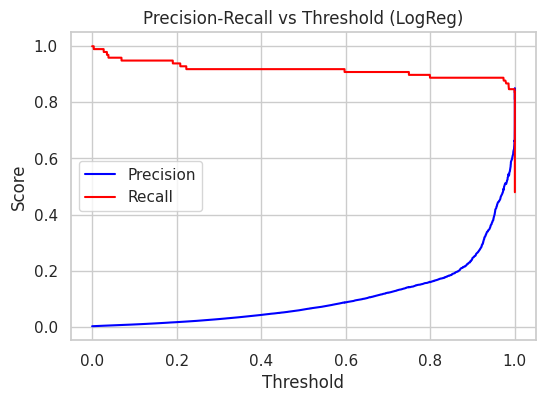

In [14]:
# Probabilités brutes LogReg
y_proba = log_model.predict_proba(X_test)[:,1]

# Precision-Recall curve (calcul unique)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calcul du F1-score pour chaque seuil
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold based on F1-score:", best_threshold)

# Seuil métier choisi
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)


plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall vs Threshold (LogReg)")
plt.show()

dans la suite, le seuil de decision est fixé a = 0.3
Un seuil plus bas augmente le Recall (plus de fraudes detectées),
mais réduit la Precision (plus de fausses alertes).

La courbe rouge (Recall) mesure la capacité du modèle à détecter les fraudes, generalement plus élevée pour les seuils faibles.

La courbe bleue (Precision) indique la précision des prédictions frauduleuses, qui augmente avec le seuil. Le seuil doit être choisi en équilibrant ces deux critères selon l'objectif métier.



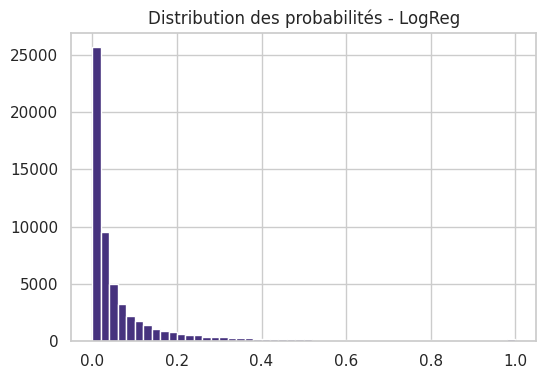

In [15]:
plt.hist(y_proba, bins=50)
plt.title("Distribution des probabilités - LogReg")
plt.show()

La majorité des transactions obtiennent une probabilité très faible.

Les transactions frauduleuses se concentrent dans la zone des probabilités élevées.

Cela confirme que le modèle parvient à séparer correctement les deux classes.

### 3.3 Calibration du modèle

In [16]:
# --- Calibration du modèle ---
from sklearn.calibration import CalibratedClassifierCV

calibrated_log = CalibratedClassifierCV(log_model, method='isotonic', cv=3)
calibrated_log.fit(X_train, y_train)

y_proba_calibrated = calibrated_log.predict_proba(X_test)[:,1]

La calibration permet d’obtenir des probabilités mieux ajustées, ce qui est particulièrement utile lorsque les probabilités sont utilisées pour du scoring ou du reporting.

### 3.4 Évaluation

In [17]:
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

# PR-AUC LogReg
pr_auc_log = average_precision_score(y_test, y_proba)
print(f"PR-AUC Logistic Regression: {pr_auc_log:.4f}")

# ROC-AUC LogReg
roc_auc_log = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Logistic Regression: {roc_auc_log:.4f}")

=== Logistic Regression ===
[[53661  3203]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.03      0.92      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.93      0.51     56962
weighted avg       1.00      0.94      0.97     56962

PR-AUC Logistic Regression: 0.7190
ROC-AUC Logistic Regression: 0.9722


Le rapport de classification montre le compromis entre précision et recall. Le Recall élevé indique que la majorité des fraudes sont correctement détectées. La Precision plus faible signifie que certaines transactions normales sont signalées à tort. Ce compromis est cohérent avec le choix d’un seuil à 0.3, qui privilégie la détection des fraudes.

# 4. Modèle 2 : XGBoost

In [18]:
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    objective='binary:logistic', eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

XGBoost est performant sur les données tabulaires et déséquilibrées.
scale_pos_weight ajuste le modèle pour tenir compte des fraudes rares.

Afin de comparer les modèles de manière cohérente, le même seuil (0.3) est appliqué aux deux modèles.

In [19]:
y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = (y_proba_xgb >= threshold).astype(int)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
# PR-AUC XGBoost
pr_auc_xgb = average_precision_score(y_test, y_proba_xgb)
print(f"PR-AUC XGBoost: {pr_auc_xgb:.4f}")
# ROC-AUC XGBoost
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC XGBoost: {roc_auc_xgb:.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC XGBoost: 0.8690
ROC-AUC XGBoost: 0.9810


Les résultats montrent que XGBoost améliore le compromis précision/recall par rapport à la régression logistique.

Le modèle détecte davantage de fraudes tout en réduisant légèrement le nombre de fausses alertes.

Le score PR-AUC confirme que le modèle est plus performant dans un contexte de classes fortement déséquilibrées.

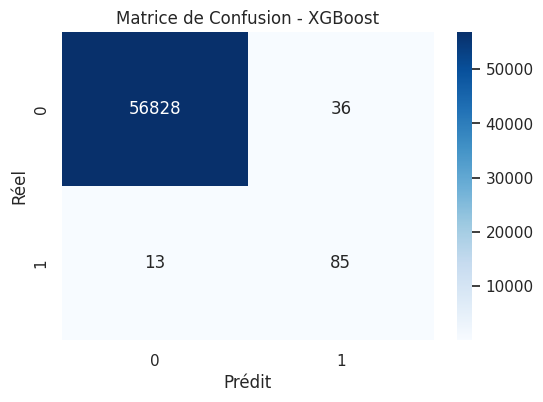

In [20]:
# Matrice de confusion visuelle
cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de Confusion - XGBoost")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


Le modèle détecte 85 fraudes sur 98 (Recall ≈ 87 %),
ce qui signifie que la grande majorité des fraudes
sont correctement identifiées.

Seules 13 fraudes ne sont pas détectées (faux négatifs),
ce qui limite les pertes financières potentielles.

Par ailleurs, seulement 36 transactions normales
sont signalées à tort (faux positifs),
ce qui représente un taux très faible
et limite l’impact sur l’expérience client.

Le modèle présente donc un bon équilibre
entre détection des fraudes et limitation
des fausses alertes.

In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "PR-AUC": [pr_auc_log, pr_auc_xgb],
    "ROC-AUC": [roc_auc_log, roc_auc_xgb]
})

print(results)

                 Model    PR-AUC   ROC-AUC
0  Logistic Regression  0.718975  0.972159
1              XGBoost  0.868982  0.980979


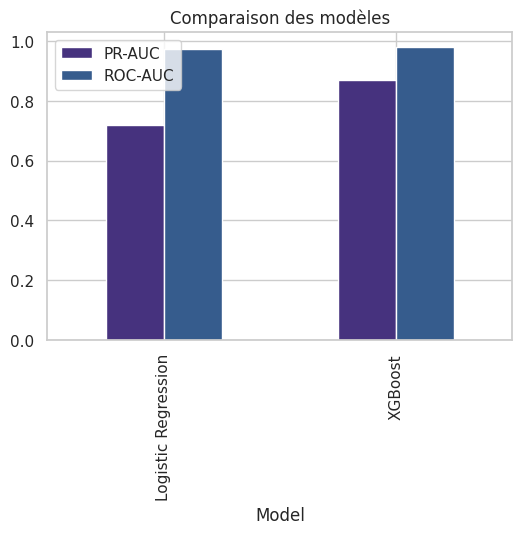

In [22]:
results.set_index("Model").plot(kind="bar")
plt.title("Comparaison des modèles")
plt.show()


XGBoost présente un PR-AUC supérieur (≈0.87 vs 0.72),
ce qui indique une meilleure capacité à détecter les fraudes
dans un contexte déséquilibré.

Le ROC-AUC est très élevé pour les deux modèles,
mais XGBoost reste légèrement meilleur,
confirmant une séparation plus nette entre classes.

Cette supériorité de XGBoost se traduit également
par une meilleure matrice de confusion,
avec moins de fraudes manquées.

Cela justifie le choix de XGBoost comme modèle final.

# 5. SHAP – Explicabilité des modèles Reg/log et XGBoost


In [23]:
# SHAP – calcul des valeurs explicatives

# Régression logistique
masker = shap.maskers.Independent(X_train)
explainer_log = shap.LinearExplainer(log_model, masker=masker)
shap_values_log = explainer_log.shap_values(X_test)

# XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Transaction frauduleuse exemple
fraud_idx = y_test[y_test == 1].index[0]

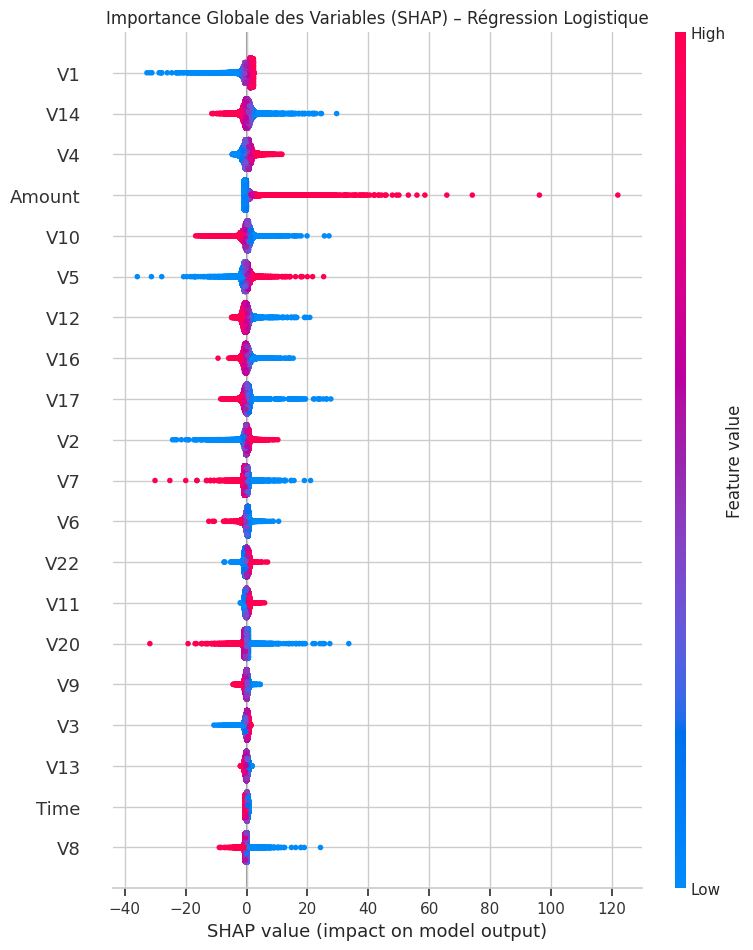

In [24]:
shap.summary_plot(shap_values_log, X_test, plot_type="dot", show=False)
plt.title("Importance Globale des Variables (SHAP) – Régression Logistique")
plt.show()

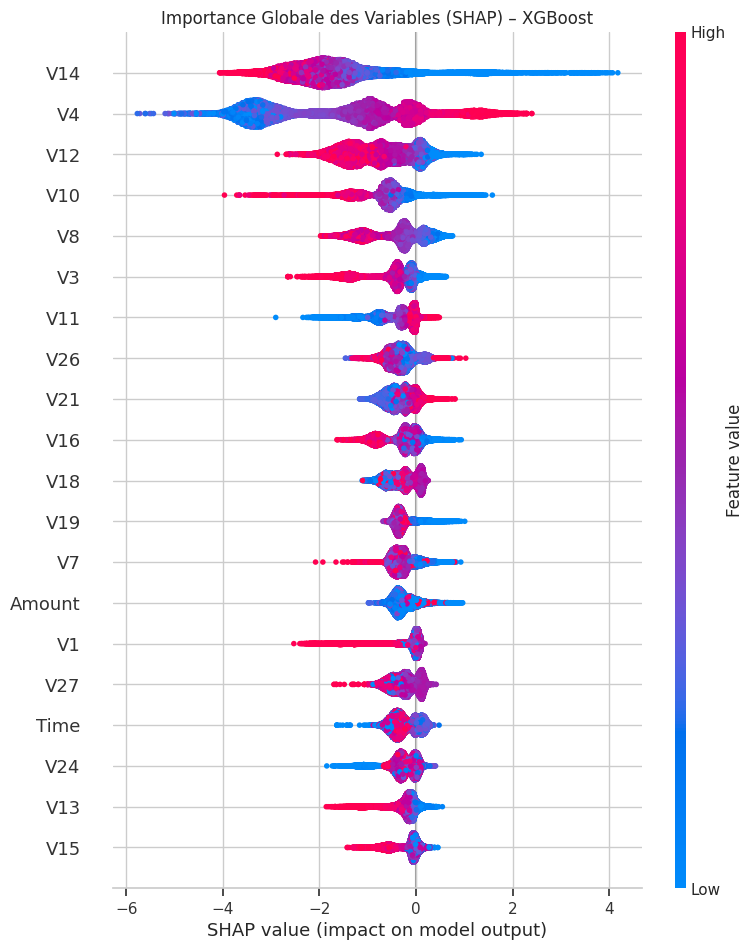

In [25]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="dot", show=False)
plt.title("Importance Globale des Variables (SHAP) – XGBoost")
plt.show()

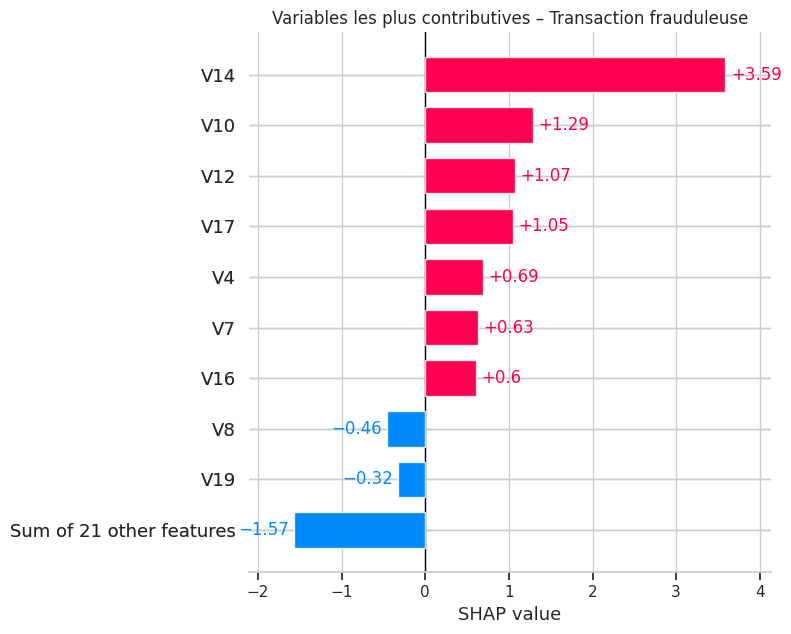

In [26]:
shap.plots.bar(
    shap.Explanation(
        values=shap_values_xgb[X_test.index.get_loc(fraud_idx)],
        base_values=explainer_xgb.expected_value,
        feature_names=X_test.columns
    ),
    max_display=10,
    show=False
)

plt.title("Variables les plus contributives – Transaction frauduleuse")
plt.tight_layout()
plt.show()

Les graphiques SHAP permettent de comprendre quelles variables influencent la prédiction de fraude, globalement et pour chaque transaction.

On observe que certaines variables issues de la transformation PCA (V1 à V28) ont un impact significatif sur la prédiction.
Cela confirme que la fraude est davantage liée à des comportements complexes qu’au simple montant de la transaction.

In [52]:
# Génération des prédictions sur l’ensemble complet
X_full = df[feature_columns].copy()
X_full["Amount"] = scaler.transform(X_full[["Amount"]])


# Prédictions XGBoost
df['Fraud_Probability'] = xgb_model.predict_proba(X_full)[:,1]
df['Fraud_Prediction'] = (df['Fraud_Probability'] >= threshold).astype(int)
df['Fraud_Prediction_Label'] = df['Fraud_Prediction'].map({0:'Normal',1:'Fraude'})

# Niveau de risque
df['Fraud_Risk_Level'] = pd.cut(
    df['Fraud_Probability'],
    bins=[0, 0.1, 0.3, 0.6, 1],
    labels=['Very_Low','Low','Medium','High']
)

In [60]:
df['Fraud_Risk_Level'].unique()


array(['Very_Low', 'High', 'Medium', 'Low'], dtype=object)

In [59]:
df['Fraud_Risk_Level'].value_counts().sort_index()

,count
Fraud_Risk_Level,
High,542
Low,328
Medium,71
Very_Low,283866


# 6. Export des résultats pour Power BI

In [68]:
# Export CSV
output_filename = "fraud_analysis_powerbi.csv"
df['Fraud_Risk_Level'] = df['Fraud_Risk_Level'].astype(str)  # Convertir la colonne catégorielle en string pour éviter les soucis d'export
df.to_csv(output_filename, index=False, encoding="utf-8-sig")       # Export du DataFrame en CSV sans index
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
df.columns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Transaction_Type', 'Amount_Category', 'Transaction_Label',
       'Fraud_Probability', 'Fraud_Prediction', 'Fraud_Prediction_Label',
       'Fraud_Risk_Level'],
      dtype='object')

## Conclusion
Dans ce projet, j’ai développé un système de détection de fraudes par carte bancaire à partir du dataset creditcard.csv. Étant donné la très faible proportion de fraudes dans les données (moins de 0,2 %), il a été crucial de gérer le fort déséquilibre des classes afin d’éviter qu’un modèle naïf prédise systématiquement des transactions normales, ce qui serait inefficace en pratique.

Après une phase d’exploration des données (EDA) pour mieux comprendre les variables, j’ai identifié que les principales caractéristiques incluent le montant (Amount), le temps écoulé depuis la première transaction (Time), ainsi que les variables transformées V1 à V28 issues d’une analyse en composantes principales (PCA), qui capturent le comportement transactionnel. Des variables métiers supplémentaires, comme Transaction_Type et Amount_Category, ont été créées pour faciliter l’analyse métier. Les visualisations ont montré que le montant seul ne suffit pas à détecter la fraude, qui peut concerner aussi bien des faibles que des montants moyens, et que la variable temporelle apporte un contexte important.

Pour la modélisation, deux approches complémentaires ont été utilisées :

Une régression logistique, simple et interprétable, qui met en lumière l’influence des variables sur le risque de fraude. Le paramètre class_weight='balanced' a permis de compenser le déséquilibre des classes. Le seuil de détection a été fixé à 0.3, privilégiant le rappel (Recall) afin d’identifier un maximum de fraudes, même si cela génère davantage de fausses alertes.

Un modèle XGBoost, plus performant pour détecter des patterns complexes dans les données déséquilibrées. Le paramètre scale_pos_weight a été utilisé pour pondérer les fraudes rares. XGBoost offre un meilleur compromis entre précision et rappel que la régression logistique, et génère les probabilités finales utilisées pour le scoring et le reporting.

Pour améliorer la compréhension des prédictions, j’ai appliqué la méthode SHAP, qui permet de visualiser quelles variables impactent le plus la prédiction de fraude pour chaque transaction, que ce soit le montant, le temps ou les variables PCA.

Enfin, les résultats ont été intégrés dans un DataFrame final contenant :

Fraud_Probability : la probabilité estimée de fraude,

Fraud_Prediction : la décision binaire selon le seuil fixé,

Fraud_Risk_Level : un niveau de risque catégorisé (Très faible, Faible, Moyen, Élevé) pour faciliter la visualisation et le reporting dans Power BI.